In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/transactions.csv', parse_dates=['date'])
df['month'] = df['date'].dt.to_period('M')
df['week']  = df['date'].dt.isocalendar().week

sns.set_theme(style='darkgrid')
print(f"Loaded {len(df)} transactions ✅")
df.head()

Loaded 1079 transactions ✅


,date,category,amount,is_anomaly,month,week
0,2024-01-01,Utilities,1088.81,0,2024-01,1
1,2024-01-01,Shopping,663.78,0,2024-01,1
2,2024-01-01,Shopping,197.81,0,2024-01,1
3,2024-01-01,Shopping,501.44,0,2024-01,1
4,2024-01-02,Entertainment,241.91,0,2024-01,1


In [8]:
print("=== Spend Statistics by Category ===\n")
print(df.groupby('category')['amount'].describe().round(2))

=== Spend Statistics by Category ===

               count     mean      std     min      25%      50%      75%  \
category                                                                    
Entertainment  166.0   353.94   318.71   19.38   239.27   308.60   389.26   
Food           187.0   414.51   148.69  246.94   351.87   394.87   459.36   
Healthcare     187.0   167.40   141.86   10.00   107.58   152.90   197.80   
Shopping       195.0   654.99   455.84   76.05   476.45   594.94   743.60   
Transport      170.0   221.78   144.43   26.09   175.98   208.59   240.43   
Utilities      174.0  1331.36  1004.86  982.33  1141.27  1207.97  1262.38   

                    max  
category                 
Entertainment   3526.59  
Food            2176.16  
Healthcare      1425.08  
Shopping        3807.84  
Transport       1621.71  
Utilities      10302.95  


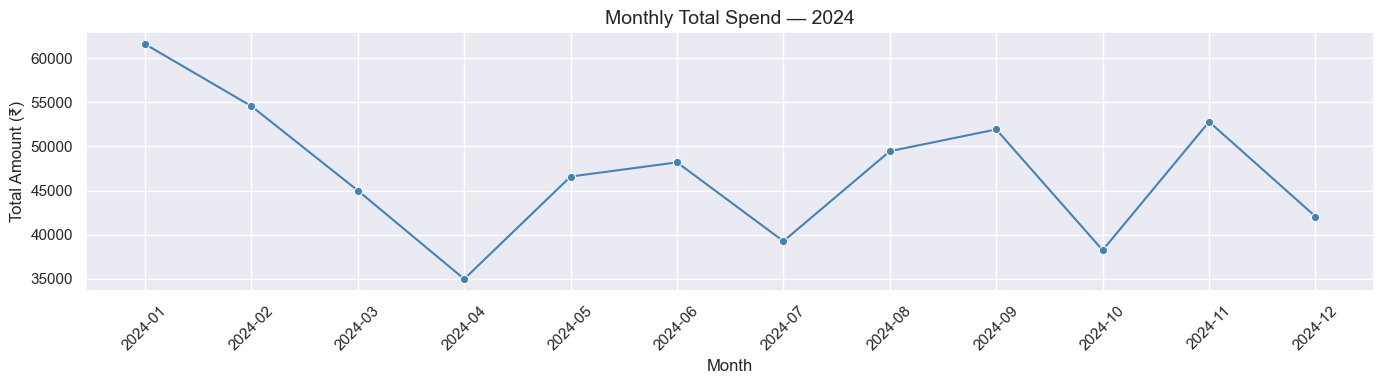

Plot saved ✅


In [9]:
import os
os.makedirs('../plots', exist_ok=True)

monthly = df.groupby('month')['amount'].sum().reset_index()
monthly['month'] = monthly['month'].astype(str)

plt.figure(figsize=(14, 4))
sns.lineplot(data=monthly, x='month', y='amount', marker='o', color='steelblue')
plt.xticks(rotation=45)
plt.title('Monthly Total Spend — 2024', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Amount (₹)')
plt.tight_layout()
plt.savefig('../plots/monthly_trend.png', dpi=150)
plt.show()
print("Plot saved ✅")

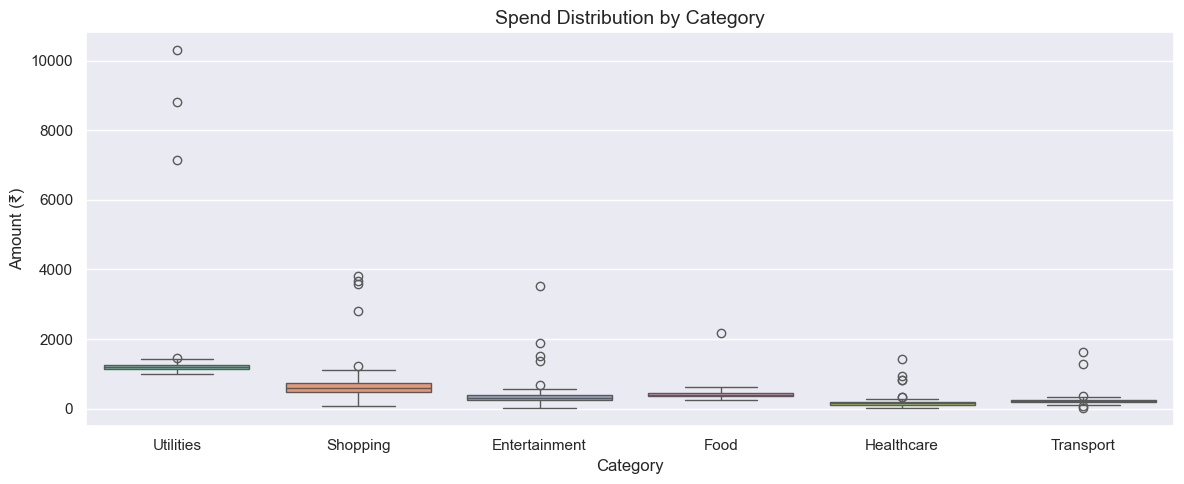

Plot saved ✅


In [10]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='category', y='amount', hue='category', palette='Set2', legend=False)
plt.title('Spend Distribution by Category', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Amount (₹)')
plt.tight_layout()
plt.savefig('../plots/category_boxplot.png', dpi=150)
plt.show()
print("Plot saved ✅")

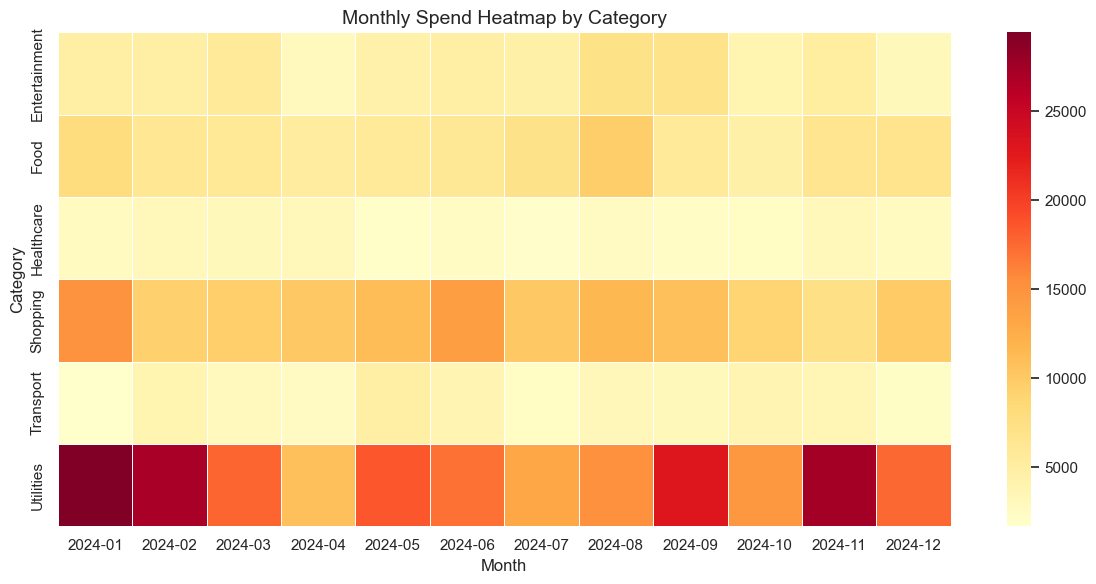

Plot saved ✅


In [11]:
import warnings
warnings.filterwarnings('ignore')

pivot = df.groupby(['month', 'category'])['amount'].sum().unstack()
pivot.index = pivot.index.astype(str)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot.T, cmap='YlOrRd', linewidths=0.5, annot=False)
plt.title('Monthly Spend Heatmap by Category', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('../plots/heatmap.png', dpi=150)
plt.show()
print("Plot saved ✅")

In [12]:
print("=== KEY FINDINGS ===\n")

top_cat = df.groupby('category')['amount'].sum().idxmax()
top_month = monthly.loc[monthly['amount'].idxmax(), 'month']
avg_daily = df.groupby('date')['amount'].sum().mean()

print(f"Highest spending category : {top_cat}")
print(f"Highest spending month    : {top_month}")
print(f"Average daily spend       : ₹{avg_daily:.2f}")
print(f"Total annual spend        : ₹{df['amount'].sum():,.2f}")

=== KEY FINDINGS ===

Highest spending category : Utilities
Highest spending month    : 2024-01
Average daily spend       : ₹1546.99
Total annual spend        : ₹564,652.69
